In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             silhouette_score, davies_bouldin_score, precision_recall_fscore_support)
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r'X:\nasim_xhqpjmy\Code\MLops\Race-Telemetry\dataset\data.csv')
df.head(3)

,Unnamed: 0,since_last_ns,timestamp_ms,current_engine_rpm,wheel_rotation_speed_front_left,wheel_rotation_speed_front_right,wheel_rotation_speed_rear_left,wheel_rotation_speed_rear_right,wheel_on_rumble_strip_front_left,wheel_on_rumble_strip_front_right,...,clutch,handbrake,gear,steer,lap_number,best_lap_time,last_lap_time,current_lap_time,current_race_time,race_position
0,0,0,27901812,4985.9053,66.646460,66.550380,65.24955,65.15579,False,False,...,0,0,2,1,0,0.0,0.0,0.000000,0.000000,1
1,1,7438900,27901828,4985.5083,66.634400,66.541245,65.25467,65.16427,False,False,...,0,0,2,1,0,0.0,0.0,0.008331,0.008331,1
2,2,8171000,27901828,4964.7420,66.630806,66.537970,65.23924,65.13835,False,False,...,0,0,2,1,0,0.0,0.0,0.016670,0.016670,1


In [3]:
df.shape

(94519, 73)

In [4]:
df.describe()

,Unnamed: 0,since_last_ns,timestamp_ms,current_engine_rpm,wheel_rotation_speed_front_left,wheel_rotation_speed_front_right,wheel_rotation_speed_rear_left,wheel_rotation_speed_rear_right,wheel_in_puddle_depth_front_left,wheel_in_puddle_depth_front_right,...,clutch,handbrake,gear,steer,lap_number,best_lap_time,last_lap_time,current_lap_time,current_race_time,race_position
count,94519.000000,9.451900e+04,9.451900e+04,94519.000000,94519.000000,94519.000000,94519.000000,94519.000000,94519.0,94519.0,...,94519.0,94519.000000,94519.000000,94519.000000,94519.000000,94519.000000,94519.000000,94519.000000,94519.000000,94519.0
mean,47259.000000,8.334302e+06,2.829569e+07,5495.815953,116.471991,116.636347,117.143681,117.499726,0.0,0.0,...,0.0,0.089030,3.325681,-0.406130,1.978481,125.727530,125.815190,78.566784,393.875511,1.0
std,27285.429384,3.268981e+05,2.274057e+05,1222.555635,32.722553,32.545618,32.529608,33.354713,0.0,0.0,...,0.0,4.763916,0.725515,81.893547,1.414813,63.994121,64.019286,45.518761,227.405753,0.0
min,0.000000,0.000000e+00,2.790181e+07,1409.790900,18.166954,29.800272,21.423563,2.025307,0.0,0.0,...,0.0,0.000000,1.000000,-127.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
25%,23629.500000,8.231000e+06,2.809876e+07,4619.970450,90.796715,92.130205,92.548887,92.226977,0.0,0.0,...,0.0,0.000000,3.000000,-57.000000,1.000000,155.704850,155.704850,39.153138,196.942105,1.0
50%,47259.000000,8.330200e+06,2.829569e+07,5576.617700,117.346510,117.645820,117.499664,118.083080,0.0,0.0,...,0.0,0.000000,3.000000,0.000000,2.000000,155.704850,158.160490,78.544266,393.867520,1.0
75%,70888.500000,8.431500e+06,2.849262e+07,6439.136350,143.308360,142.791505,143.975325,143.324705,0.0,0.0,...,0.0,0.000000,4.000000,50.000000,3.000000,160.796810,158.836640,117.929530,590.809530,1.0
max,94518.000000,2.228670e+07,2.868956e+07,8031.248000,191.640370,190.089630,193.419050,196.278370,0.0,0.0,...,0.0,255.000000,4.000000,127.000000,4.000000,160.796810,160.796810,160.789260,787.751600,1.0


In [5]:
df.dtypes

Unnamed: 0                           int64
since_last_ns                        int64
timestamp_ms                         int64
current_engine_rpm                 float64
wheel_rotation_speed_front_left    float64
                                    ...   
best_lap_time                      float64
last_lap_time                      float64
current_lap_time                   float64
current_race_time                  float64
race_position                        int64
Length: 73, dtype: object

In [6]:
df.isnull().sum()

Unnamed: 0                         0
since_last_ns                      0
timestamp_ms                       0
current_engine_rpm                 0
wheel_rotation_speed_front_left    0
                                  ..
best_lap_time                      0
last_lap_time                      0
current_lap_time                   0
current_race_time                  0
race_position                      0
Length: 73, dtype: int64

In [7]:
# Create a copy for processing
df_processed = df.copy()

In [8]:
df_processed = df_processed.fillna(0)

In [9]:
# Wheel slip magnitude (combined front and rear)
df_processed['wheel_slip_magnitude_front'] = np.sqrt(
    df_processed['tire_slip_rotation_front_left']**2 + 
    df_processed['tire_slip_rotation_front_right']**2
)
df_processed['wheel_slip_magnitude_rear'] = np.sqrt(
    df_processed['tire_slip_rotation_rear_left']**2 + 
    df_processed['tire_slip_rotation_rear_right']**2
)
print("Wheel slip magnitude features created.",df_processed['wheel_slip_magnitude_front'].head())
print("Wheel slip magnitude features created.",df_processed['wheel_slip_magnitude_rear'].head())

Wheel slip magnitude features created. 0    0.000471
1    0.000575
2    0.000617
3    0.000805
4    0.001093
Name: wheel_slip_magnitude_front, dtype: float64
Wheel slip magnitude features created. 0    0.003831
1    0.000227
2    0.002271
3    0.001657
4    0.008228
Name: wheel_slip_magnitude_rear, dtype: float64


In [10]:
# Tire stress (combined slip)
df_processed['tire_stress_front'] = (
    df_processed['tire_combined_slip_front_left'] + 
    df_processed['tire_combined_slip_front_right']
) / 2
df_processed['tire_stress_rear'] = (
    df_processed['tire_combined_slip_rear_left'] + 
    df_processed['tire_combined_slip_rear_right']
) / 2
print("Tire stress features created.",df_processed['tire_stress_front'].head())
print("Tire stress features created.",df_processed['tire_stress_rear'].head())

Tire stress features created. 0    0.013216
1    0.014198
2    0.010561
3    0.000687
4    0.006213
Name: tire_stress_front, dtype: float64
Tire stress features created. 0    0.010619
1    0.011365
2    0.010795
3    0.010709
4    0.012440
Name: tire_stress_rear, dtype: float64


In [11]:
# Average tire temperature
df_processed['avg_tire_temp'] = (
    df_processed['tire_temp_front_left'] + 
    df_processed['tire_temp_front_right'] +
    df_processed['tire_temp_rear_left'] + 
    df_processed['tire_temp_rear_right']
) / 4
print("Average tire temperature feature created.",df_processed['avg_tire_temp'].head())

Average tire temperature feature created. 0    121.800833
1    121.802080
2    121.803559
3    121.805011
4    121.806404
Name: avg_tire_temp, dtype: float64


In [12]:
# Suspension travel metrics
df_processed['avg_suspension_travel'] = (
    df_processed['suspension_travel_meters_front_left'] +
    df_processed['suspension_travel_meters_front_right'] +
    df_processed['suspension_travel_meters_rear_left'] +
    df_processed['suspension_travel_meters_rear_right']
) / 4
print("Average suspension travel feature created.",df_processed['avg_suspension_travel'].head())

Average suspension travel feature created. 0    0.001171
1    0.001582
2    0.001735
3    0.002128
4    0.002746
Name: avg_suspension_travel, dtype: float64


In [13]:
# Acceleration magnitude
df_processed['acceleration_magnitude'] = np.sqrt(
    df_processed['acceleration_x']**2 + 
    df_processed['acceleration_y']**2 + 
    df_processed['acceleration_z']**2
)
print("Acceleration magnitude feature created.",df_processed['acceleration_magnitude'].head())

Acceleration magnitude feature created. 0    0.520102
1    2.145005
2    1.679090
3    1.275940
4    0.840998
Name: acceleration_magnitude, dtype: float64


In [14]:
# Velocity magnitude
df_processed['velocity_magnitude'] = np.sqrt(
    df_processed['velocity_x']**2 + 
    df_processed['velocity_y']**2 + 
    df_processed['velocity_z']**2
)
print("Velocity magnitude feature created.",df_processed['velocity_magnitude'].head())


Velocity magnitude feature created. 0    21.785470
1    21.782807
2    21.780424
3    21.777562
4    21.773473
Name: velocity_magnitude, dtype: float64


In [15]:
# Steering rate (change in steering)
df_processed['steering_rate'] = df_processed['steer'].diff().fillna(0)
print("Steering rate feature created.",df_processed['steering_rate'].head())

Steering rate feature created. 0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: steering_rate, dtype: float64


In [16]:
# Brake-acceleration interaction
df_processed['brake_accel_interaction'] = df_processed['brake'] * df_processed['acceleration']
print("Brake-acceleration interaction feature created.",df_processed['brake_accel_interaction'].head())

Brake-acceleration interaction feature created. 0    0
1    0
2    0
3    0
4    0
Name: brake_accel_interaction, dtype: int64


In [17]:
# RPM per speed ratio
df_processed['rpm_speed_ratio'] = df_processed['current_engine_rpm'] / (df_processed['speed'] + 1)
print("RPM per speed ratio feature created.",df_processed['rpm_speed_ratio'].head())

RPM per speed ratio feature created. 0    218.819497
1    218.827668
2    217.938945
3    217.296136
4    216.918376
Name: rpm_speed_ratio, dtype: float64


In [18]:
print(f"Total features after engineering: {df_processed.shape[1]}")

Total features after engineering: 84


In [19]:
numeric_features = [
    'current_engine_rpm', 'speed', 'power', 'torque', 'boost', 'fuel',
    'acceleration_x', 'acceleration_y', 'acceleration_z',
    'velocity_x', 'velocity_y', 'velocity_z',
    'angular_velocity_x', 'angular_velocity_y', 'angular_velocity_z',
    'yaw', 'pitch', 'roll',
    'wheel_slip_magnitude_front', 'wheel_slip_magnitude_rear',
    'tire_stress_front', 'tire_stress_rear',
    'avg_tire_temp', 'avg_suspension_travel',
    'acceleration_magnitude', 'velocity_magnitude',
    'steering_rate', 'rpm_speed_ratio',
    'steer', 'distance_traveled'
]

In [20]:
categorical_features = ['gear', 'lap_number', 'race_position']

In [21]:
# Encode categorical features
le_gear = LabelEncoder()
le_lap = LabelEncoder()
le_pos = LabelEncoder()

In [22]:
df_processed['gear_encoded'] = le_gear.fit_transform(df_processed['gear'].astype(str))
df_processed['lap_encoded'] = le_lap.fit_transform(df_processed['lap_number'].astype(str))
df_processed['position_encoded'] = le_pos.fit_transform(df_processed['race_position'].astype(str))

In [23]:
# Create master feature list
all_features = numeric_features + ['gear_encoded', 'lap_encoded', 'position_encoded']

In [24]:
print("\nNormalizing features...")
scaler = StandardScaler()
df_processed[numeric_features] = scaler.fit_transform(df_processed[numeric_features])

print("Preprocessing complete!")


Normalizing features...
Preprocessing complete!


In [25]:
gear_brake_features = [
    'current_engine_rpm', 'speed', 'acceleration_magnitude',
    'velocity_magnitude', 'power', 'torque', 'rpm_speed_ratio',
    'acceleration_x', 'acceleration_y', 'acceleration_z',
    'brake_accel_interaction', 'steer', 'steering_rate'
]

In [26]:
X_gear_brake = df_processed[gear_brake_features]
# Prepare targets: gear and brake (binary)
df_processed['brake_binary'] = (df_processed['brake'] > 0).astype(int)
y_gear = df_processed['gear']
y_brake = df_processed['brake_binary']

In [27]:
y_gear_brake = pd.DataFrame({
    'gear': y_gear,
    'brake': y_brake
})

In [28]:
X_gb_train, X_gb_test, y_gb_train, y_gb_test = train_test_split(
    X_gear_brake, y_gear_brake, test_size=0.2, random_state=42
)

In [29]:
print(f"\nTraining samples: {len(X_gb_train)}")
print(f"Testing samples: {len(X_gb_test)}")
print(f"Target 1: Gear (classes: {y_gear.nunique()})")
print(f"Target 2: Brake (classes: {y_brake.nunique()})")


Training samples: 75615
Testing samples: 18904
Target 1: Gear (classes: 4)
Target 2: Brake (classes: 2)


In [32]:
best_params = {
    'n_estimators': 10,
    'max_depth': 5,
    'min_samples_split': 2,
    'min_samples_leaf': 1,
    'max_features': 'sqrt'
}

best_rf = MultiOutputClassifier(RandomForestClassifier(random_state=42, n_jobs=-1, **best_params))

print("\nTraining RandomForest Classifier with best parameters...")
best_rf.fit(X_gb_train, y_gb_train)

y_pred_train = best_rf.predict(X_gb_train)
y_pred_test = best_rf.predict(X_gb_test)

y_pred_train_gear, y_pred_train_brake = y_pred_train[:, 0], y_pred_train[:, 1]
y_pred_test_gear, y_pred_test_brake = y_pred_test[:, 0], y_pred_test[:, 1]

#Evaluation 
train_acc_gear = accuracy_score(y_gb_train['gear'], y_pred_train_gear)
test_acc_gear = accuracy_score(y_gb_test['gear'], y_pred_test_gear)

train_acc_brake = accuracy_score(y_gb_train['brake'], y_pred_train_brake)
test_acc_brake = accuracy_score(y_gb_test['brake'], y_pred_test_brake)

print("\nTest Accuracies:")
print(f" Gear:  {test_acc_gear:.4f}")
print(f" Brake: {test_acc_brake:.4f}")
print("\nClassification Report (Gear):")
print(classification_report(y_gb_test['gear'], y_pred_test_gear))
print("\nClassification Report (Brake):")
print(classification_report(y_gb_test['brake'], y_pred_test_brake))
print("\nTraining completed successfully.")


Training RandomForest Classifier with best parameters...

Test Accuracies:
 Gear:  0.9860
 Brake: 0.9775

Classification Report (Gear):
              precision    recall  f1-score   support

           1       0.99      0.96      0.97       408
           2       0.99      0.96      0.97      1584
           3       0.99      0.98      0.99      8334
           4       0.98      1.00      0.99      8578

    accuracy                           0.99     18904
   macro avg       0.99      0.97      0.98     18904
weighted avg       0.99      0.99      0.99     18904


Classification Report (Brake):
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     15868
           1       0.93      0.93      0.93      3036

    accuracy                           0.98     18904
   macro avg       0.96      0.96      0.96     18904
weighted avg       0.98      0.98      0.98     18904


Training completed successfully.


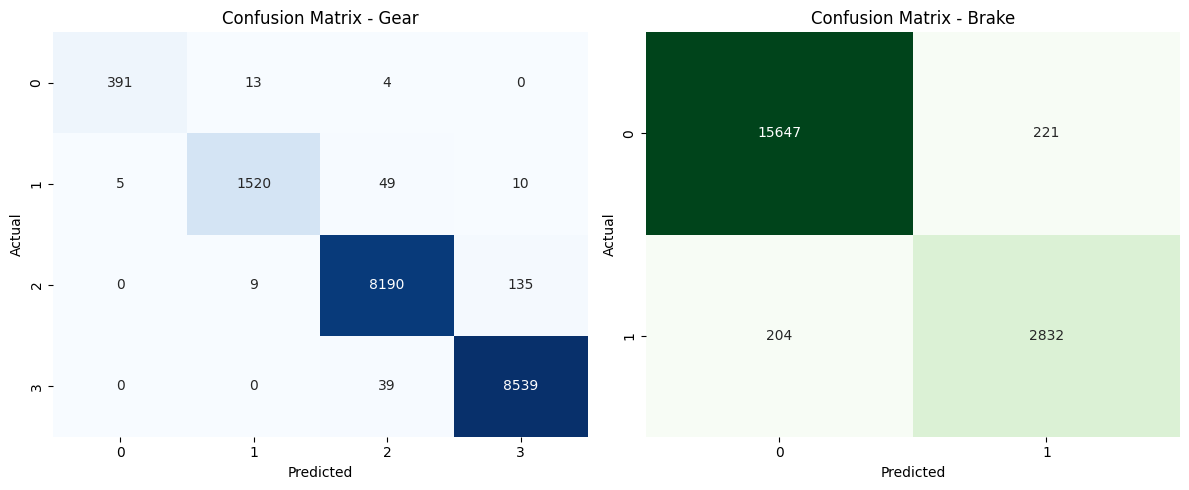

In [36]:
cm_gear = confusion_matrix(y_gb_test['gear'], y_pred_test_gear)
cm_brake = confusion_matrix(y_gb_test['brake'], y_pred_test_brake)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: Gear confusion matrix
sns.heatmap(cm_gear, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0])
axes[0].set_title("Confusion Matrix - Gear")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Right: Brake confusion matrix
sns.heatmap(cm_brake, annot=True, fmt='d', cmap='Greens', cbar=False, ax=axes[1])
axes[1].set_title("Confusion Matrix - Brake")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
plt.tight_layout()
plt.show()

In [38]:
save_dir = "saved_models"
os.makedirs(save_dir, exist_ok=True)  

model_path = os.path.join(save_dir, "classication.pkl")
joblib.dump(best_rf, model_path)

print(f"Model saved successfully at {model_path}")

Model saved successfully at saved_models\classication.pkl
